# MNIST Model Training

> Training an MLP on a simple binary classification task

Imports

In [ ]:
from learningdynamics.models import MLP, init_weights
import matplotlib.pyplot as plt
import matplotlib
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from safetensors.torch import save_model
from torch.optim import SGD, AdamW
from torchvision import datasets, transforms
import torch
from learningdynamics.utils import (
    compute_model_accuracy,
    getActivation,
    safetensors_metadata_parser,
)
from torch.optim.lr_scheduler import ReduceLROnPlateau

Notebook configuration

In [ ]:
# Visualization
FIGSIZE = (5, 5)
matplotlib.rc("figure", figsize=FIGSIZE)

# MLP settings
HIDDEN_NEURONS = [256, 128, 64, 32]  # only valid for HiddenLayerModel
NONLINEARITY = "relu"

# Model training settings
BATCH_SIZE = 4_096
NUM_EPOCHS = 30
LEARNING_RATE = 1e-2
PRINT_FREQ = 1

Define a YinYang dataset

In [ ]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),  # first, convert image to PyTorch tensor
        transforms.Normalize((0.1307,), (0.3081,)),  # normalize inputs
    ]
)
train_set = datasets.MNIST(
    root="/mnt/datasets/", train=True, download=True, transform=transform
)
test_set = datasets.MNIST(
    root="/mnt/datasets/", train=False, download=True, transform=transform
)

Visualize the dataset as a sanity check.

<matplotlib.image.AxesImage>

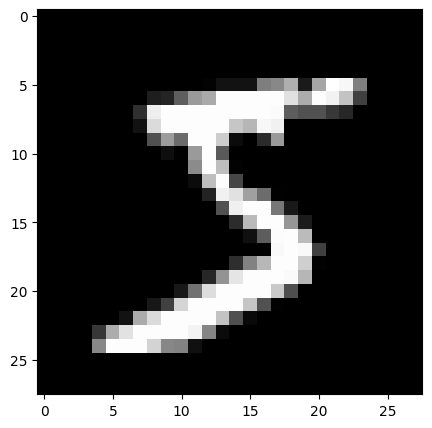

In [ ]:
plt.imshow(train_set.data[0], cmap="gray")

Define a MLP model

In [ ]:
model = MLP(
    config=HIDDEN_NEURONS,
    in_features=torch.flatten(train_set.data, start_dim=1).shape[-1],
    out_features=10,
    nonlinearity=NONLINEARITY,
)
model.apply(init_weights)

MLP(
  (features): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=10, bias=True)
  )
)

Setup model training

In [ ]:
dataloader = DataLoader(dataset=train_set, shuffle=True, batch_size=BATCH_SIZE)
criterion = CrossEntropyLoss()  # Use CrossEntropyLoss for multi-class classification
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.1)
scheduler = ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1, threshold=0.0001, verbose=True
)

Train the model

In [ ]:
device = "cuda:0"
model.to(device=device)
model.train()

loss_vector = []
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0  # Track loss within the epoch

    for batch_idx, (input, label) in enumerate(dataloader):
        input, label = input.to(device), label.to(device)
        label = label.squeeze()

        optimizer.zero_grad()
        output = model(input)

        loss = criterion(output, label.long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()  # Accumulate loss

    epoch_loss = running_loss / len(dataloader)  # Average loss over all batches
    loss_vector.append(epoch_loss)  # Store loss for later analysis

    # Step the scheduler
    scheduler.step(epoch_loss)

    if (epoch + 1) % PRINT_FREQ == 0:
        print(f"Epoch {epoch + 1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}")

Epoch 1/30, Loss: 1.6791
Epoch 2/30, Loss: 0.6583
Epoch 3/30, Loss: 0.3877
Epoch 4/30, Loss: 0.2888
Epoch 5/30, Loss: 0.2344
Epoch 6/30, Loss: 0.1988
Epoch 7/30, Loss: 0.1725
Epoch 8/30, Loss: 0.1529
Epoch 9/30, Loss: 0.1370
Epoch 10/30, Loss: 0.1242
Epoch 11/30, Loss: 0.1121
Epoch 12/30, Loss: 0.1019
Epoch 13/30, Loss: 0.0931
Epoch 14/30, Loss: 0.0867
Epoch 15/30, Loss: 0.0793
Epoch 16/30, Loss: 0.0730
Epoch 17/30, Loss: 0.0681
Epoch 18/30, Loss: 0.0633
Epoch 19/30, Loss: 0.0576
Epoch 20/30, Loss: 0.0534
Epoch 21/30, Loss: 0.0499
Epoch 22/30, Loss: 0.0465
Epoch 23/30, Loss: 0.0425
Epoch 24/30, Loss: 0.0394
Epoch 25/30, Loss: 0.0368
Epoch 26/30, Loss: 0.0344
Epoch 27/30, Loss: 0.0312
Epoch 28/30, Loss: 0.0292
Epoch 29/30, Loss: 0.0273
Epoch 30/30, Loss: 0.0253


In [ ]:
compute_model_accuracy(model.cpu(), test_set)

tensor(0.9720)

Save the model using `safetensors`

In [ ]:
metadata_dict = {
    "config": str(HIDDEN_NEURONS),
    "dataset": "MNIST",
    "nonlinearity": str(NONLINEARITY),
}
save_model(model, "../saved_weights/mnist_model.safetensors", metadata=metadata_dict)